In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/raw/monthly-housing.csv")
df.head(3)

,date,hpi,numsold
0,1/1/1991,100.00,30
1,2/1/1991,100.48,40
2,3/1/1991,100.74,51


## Remove null value

In [3]:
print(df.shape)
print(df[["date", "hpi"]].isnull().sum())

(280, 3)
date    12
hpi     12
dtype: int64


In [4]:
df_clean = df.dropna(subset=["date", "hpi"]).copy()
print(df_clean[["date", "hpi"]].isnull().sum())
print(df_clean.shape)

date    0
hpi     0
dtype: int64
(268, 3)


## Change date format

In [5]:
df_clean["date"] = pd.to_datetime(df_clean["date"])
df_clean = df_clean.sort_values("date").reset_index(drop=True)
df_clean = df_clean.set_index("date")
df_clean = df_clean.asfreq("MS") # set as the beginning of the month

In [6]:
print(df_clean.index)
print(df_clean.head(3))
print(df_clean.tail(3))

DatetimeIndex(['1991-01-01', '1991-02-01', '1991-03-01', '1991-04-01',
               '1991-05-01', '1991-06-01', '1991-07-01', '1991-08-01',
               '1991-09-01', '1991-10-01',
               ...
               '2012-07-01', '2012-08-01', '2012-09-01', '2012-10-01',
               '2012-11-01', '2012-12-01', '2013-01-01', '2013-02-01',
               '2013-03-01', '2013-04-01'],
              dtype='datetime64[ns]', name='date', length=268, freq='MS')
               hpi  numsold
date                       
1991-01-01  100.00       30
1991-02-01  100.48       40
1991-03-01  100.74       51
               hpi  numsold
date                       
2013-02-01  194.31       36
2013-03-01  198.06       41
2013-04-01  200.87       43


## Visualize `df_clean`

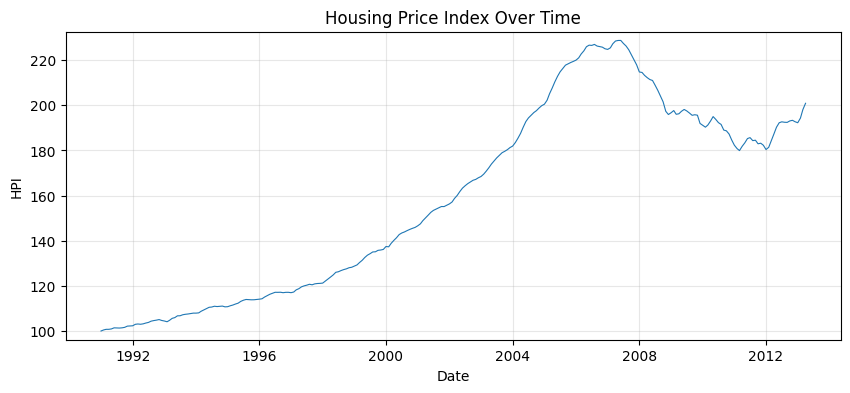

In [7]:
plt.figure(figsize=(10, 4))

plt.plot(
    df_clean.index,
    df_clean["hpi"],
    linewidth=0.8
)

y_min = df_clean["hpi"].min()
y_max = df_clean["hpi"].max()
padding = (y_max - y_min) * 0.03

plt.ylim(y_min - padding, y_max + padding)

plt.title("Housing Price Index Over Time")
plt.xlabel("Date")
plt.ylabel("HPI")
plt.grid(True, alpha=0.3)

plt.show()

## save df_clean (到這就好)

In [8]:
df_clean.to_csv("data/processed/monthly_housing_clean.csv", index=True)

## log HPI

In [9]:
df_clean["log_hpi"] = np.log(df_clean["hpi"])

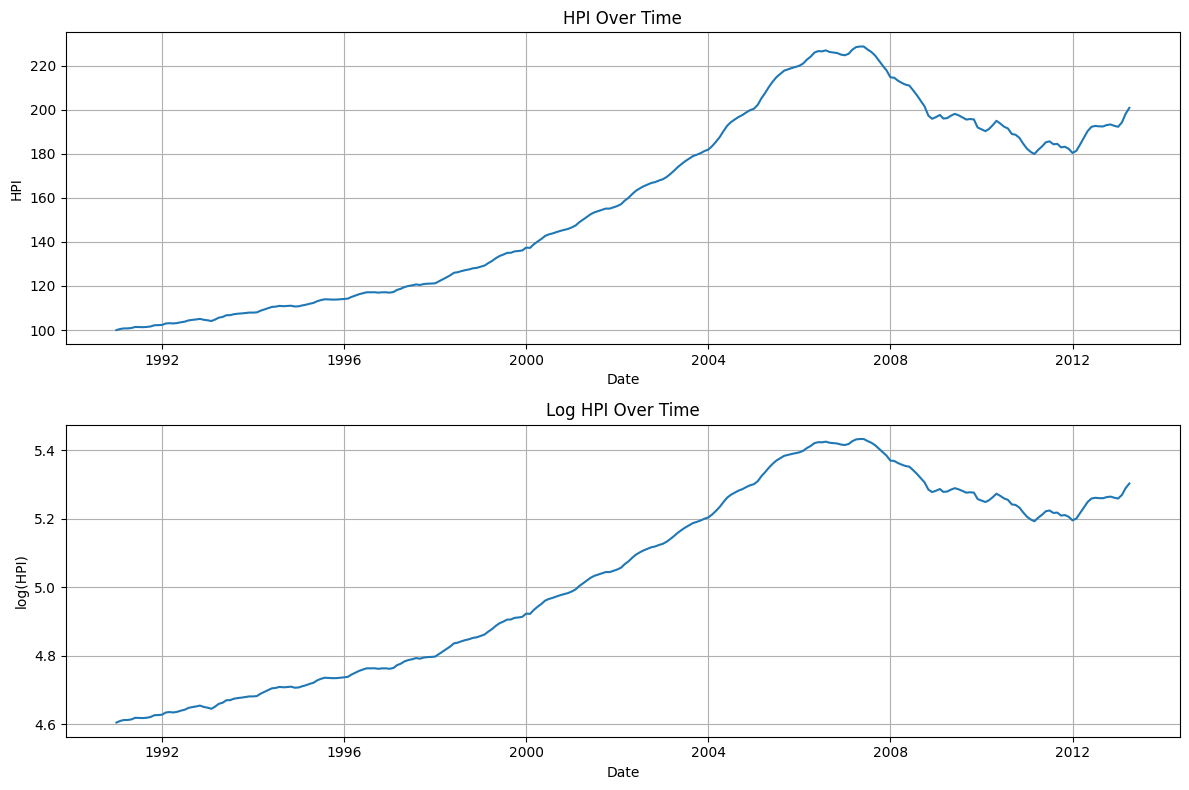

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

axes[0].plot(df_clean.index, df_clean["hpi"])
axes[0].set_title("HPI Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("HPI")
axes[0].grid(True)

axes[1].plot(df_clean.index, df_clean["log_hpi"])
axes[1].set_title("Log HPI Over Time")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("log(HPI)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [23]:
df_clean.head(3)

,hpi,numsold,log_hpi
date,,,
1991-01-01,100.00,30,4.605170
1991-02-01,100.48,40,4.609959
1991-03-01,100.74,51,4.612543


In [27]:
df_clean.to_csv("data/processed/monthly_housing_clean.csv", index=True)

## train test split

In [29]:
train = df_clean.iloc[:-12].copy()
test = df_clean.iloc[-12:].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print(train.head(3))
print(train.tail(3))

print(test.head(3))
print(test.tail(3))

Train shape: (256, 3)
Test shape: (12, 3)
               hpi  numsold   log_hpi
date                                 
1991-01-01  100.00       30  4.605170
1991-02-01  100.48       40  4.609959
1991-03-01  100.74       51  4.612543
               hpi  numsold   log_hpi
date                                 
2012-02-01  181.36       30  5.200484
2012-03-01  184.15       34  5.215751
2012-04-01  187.26       34  5.232498
               hpi  numsold   log_hpi
date                                 
2012-05-01  190.29       35  5.248549
2012-06-01  192.25       34  5.258797
2012-07-01  192.66       33  5.260927
               hpi  numsold   log_hpi
date                                 
2013-02-01  194.31       36  5.269455
2013-03-01  198.06       41  5.288570
2013-04-01  200.87       43  5.302658


In [30]:
train.to_csv("data/processed/monthly_housing_train.csv", index=True)
test.to_csv("data/processed/monthly_housing_test.csv", index=True)